In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. 비지도학습

## 데이터 전처리

### 환경설정

In [3]:
!pip install prince

In [4]:
!pip install koreanize-matplotlib

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from prince import FAMD
from sklearn.cluster import DBSCAN
import umap.umap_ as umap
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
import json

### 데이터 샘플링

In [6]:
df = pd.read_csv('/content/drive/MyDrive/FDS/df_mapping.csv')

identity = ['TransactionDT', 'recipient', 'DeviceInfo', 'region', 'receiver_bank','receiver_account', 'ip_address', 'app_version']
categories_col = ['voice_match', 'is_new_account_for_user', 'is_nighttime', 'is_new_device', 'vpn', 'payment_method', 'intent', 'authentication', 'rooting']
numerics_col = ['TransactionAmt', 'hour', 'avg_amount_to_bank', 'recent_transaction_gap'] #float32

In [7]:
df_cleansing = df.sample(frac=0.1, random_state=42)

In [8]:
id_df = pd.concat([df_cleansing[identity], df_cleansing['transaction_time']], axis=1)
sampled_df = df_cleansing.drop(columns = identity, axis=1)
sampled_df.drop(columns = 'transaction_time', axis=1, inplace=True)

In [9]:
id_df.head()

,TransactionDT,recipient,DeviceInfo,region,receiver_bank,receiver_account,ip_address,app_version,transaction_time
470624,12153579,재호,Unknown,부산,우리은행,1000000445030,179.119.115.145,3.5.6,2025-04-21 20:50:45
565820,15005886,서준,Unknown,부산,하나은행,1000000303137,209.41.212.100,2.7.2,2025-01-18 01:17:51
284083,6970178,영환,Unknown,국외,우리은행,1000000271710,51.107.78.56,1.1.2,2025-01-15 19:53:37
239689,5673658,하은,Unknown,서울,우리은행,1000000467392,216.189.238.124,1.6.0,2025-03-20 06:27:15
281855,6886780,영길,Unknown,서울,신한은행,1000000084741,80.107.183.18,1.5.0,2025-03-12 15:15:26


### 재현성 설정

In [10]:
def seed_everything(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.mamual_seed_all(seed)
  seed_everything()

# device 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 전처리 및 분할

In [11]:
X = sampled_df.astype(np.float32).values # float32 타입의 array로 변환

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 분할
X_train, X_val = train_test_split(X_scaled, test_size=0.1, random_state=42, shuffle=True)

## 1-1. Isolation Forest

In [12]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
# 이상여부 예측
iso_scores = -iso.fit_predict(X_scaled)

In [13]:
# -1 해주는 이유: decision_function은 이상할 수록 작은 값이므로 부호 반전을 위해 -1 곱해줌
sampled_df['if_anomaly_score'] = iso.decision_function(X_scaled) * -1
# anomaly_flag 설정(1이 정상, -1이 이상인데 -> 부호 반전을 통해 1이 anomaly_flag로 변환)
sampled_df['if_anomaly_flag'] = (iso_scores == 1).astype(int)

In [14]:
sampled_df.head(1)

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,intent_T03,intent_T04,intent_T05,authentication_A02,authentication_A03,authentication_A04,authentication_A05,authentication_A06,if_anomaly_score,if_anomaly_flag
470624,724000.0,20,426528,1.697427,26.15878,0,0,0,0,1,...,0,1,0,0,1,0,0,0,-0.005678,0


## 1-2. Autoencoder

In [15]:
'''
Autoencoder는 입력 데이터를 압축(encoding)하고 다시 원래대로 복원(decoding)하는 방식으로 학습하는 신경망
이 방식을 통해서 데이터의 이상값을 감지함
(왜냐하면 정상값은 잘 복원되는데 이상거래는 학습되지 않은 패턴이라 복원 오류(MSE)가 커짐)
'''
class Autoencoder(nn.Module):
  def __init__(self, input_dim):
    super(Autoencoder, self).__init__()

    # 1. encoder: 데이터를 저차원(latent vector)으로 압축하는 단계
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 16), # input -> 16차원 압축
        nn.ReLU(),
        nn.Linear(16, 8) # 16 -> 8차원 latent vector
    )

    # 2. decoder: 복원 단계
    self.decoder = nn.Sequential(
        nn.Linear(8, 16), # 8차원 latent -> 16차원
        nn.ReLU(),
        nn.Linear(16, input_dim) # 16차원으로 복구
    )

  def forward(self, x):
    '''
    학습 및 예측시 forward 메소드 호출
    input 데이터를 encoding -> decoding 단계로 처리,
    x: 입력 데이터(batch_size, input_dim)
    return값: 복원된 데이터
    '''
    encoded = self.encoder(x) # 압축
    decoded = self.decoder(encoded) # 복원
    return decoded

In [16]:
# X_train, X_val -> pytorch 텐서로 변환 -> device에 올리기
train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

# ae 모델 initialization (input dim은 train set 기준)
model = Autoencoder(input_dim=train_tensor.shape[1]).to(device)

# loss 함수 정의: MSE(평균 제곱 오차) -> 재구성 오류 측정
criterion = nn.MSELoss()

# 최적화: Adam -> 가중치 업데이트
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
# 루프돌면서 모델 학습, 가중치 업데이트, 오버피팅 감지
for epoch in range(50):
  model.train()
  optimizer.zero_grad() # 이전 에폭에서의 gradient initialization(안해주면 계속 쌓인다)
  output = model(train_tensor) # ae통해 input 재구성
  loss = criterion(output, train_tensor) # 실제 input과 재구성 결과의 차이를 손실로 계산
  loss.backward() # loss func에 따라서 역전파
  optimizer.step() # 가중치 업뎃

# 매 10 에폭마다 val loss 확인(오버피팅 감지)
  if epoch % 10 == 0:
    model.eval() # 모델을 평가모드로 전환
    val_out = model(val_tensor) # val 데이터 재구성
    val_loss = criterion(val_out, val_tensor).item() # val loss 계산
    print(f'Epoch {epoch} - Train Loss: {loss.item():.4f} - Val Loss: {val_loss:.4f}')

Epoch 0 - Train Loss: 1.0241 - Val Loss: 0.9748
Epoch 10 - Train Loss: 1.0115 - Val Loss: 0.9629
Epoch 20 - Train Loss: 0.9998 - Val Loss: 0.9516
Epoch 30 - Train Loss: 0.9875 - Val Loss: 0.9396
Epoch 40 - Train Loss: 0.9730 - Val Loss: 0.9257


- train loss: 모델이 학습 데이터 구조를 잘 복원하는지 측정
- val loss: 과적합 여부 확인(train만 잘 맞추는 경우인지 확인)
- 위 경우 에폭마다 train-val loss가 비슷: 오버피팅이 거의 없다(학습이 안정적이고 일반화 성능이 양호)


```
재구성 손실이
- 1 ~ 2: 양호한 수준
- 5 이상: 언더피팅 가능성(input feature를 잘 복원하지 못하는 중)
- 0.1 이하: 오버피팅 가능성(과도한 복원 -> 이상탐지 감도가 약해질 수 있다)
```



In [18]:
model.eval()

# 전체 데이터셋을 텐서로 변환 -> 디바이스에 올리기
full_tensor = torch.tensor(X_scaled, dtype = torch.float32).to(device)

# ae로 전체 데이터 재구성 실행
recon = model(full_tensor)

# 재구성 오차(mse)를 각 샘플마다 계산
# 이상 거래일 수록 원본과 재구성 차이가 크다 -> score도 커진다
mse = torch.mean((full_tensor - recon)**2, dim = 1).cpu().detach().numpy() # 이상탐지 score: 재구성 실패 정도, 높을 수록 이상거래일 가능성이 높다.

In [19]:
print("MSE 최소값:", np.min(mse))
print("MSE 최대값:", np.max(mse))
print("MSE 평균:", np.mean(mse))
print("MSE 상위 5% 기준:", np.percentile(mse, 95))

MSE 최소값: 0.31728953
MSE 최대값: 2159.1265
MSE 평균: 0.950975
MSE 상위 5% 기준: 1.1716423


In [20]:
diff = (full_tensor - recon).cpu().detach().numpy()
print("평균 차이:", np.mean(np.abs(diff)))

평균 차이: 0.7516346


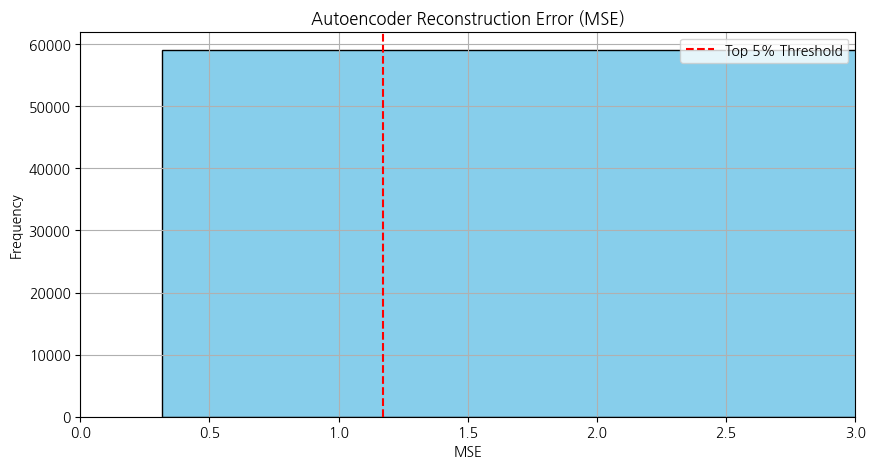

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# MSE 분포 히스토그램 (이상치로 인한 왜곡 방지 위해 xlim 조정)
plt.hist(mse, bins=50, color='skyblue', edgecolor='black')

# 상위 5% 기준선 표시
threshold_95 = np.percentile(mse, 95)
plt.axvline(threshold_95, color='red', linestyle='--', label='Top 5% Threshold')

# 시각적으로 보기 좋은 범위로 x축 제한 설정
plt.xlim(0, 3)

plt.title("Autoencoder Reconstruction Error (MSE)")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# anomaly score -> 높은 값일 수록 anomaly하다고 판단
sampled_df['ae_anomaly_score'] = mse
sampled_df['ae_anomaly_flag'] = (sampled_df['ae_anomaly_score'] > np.percentile(mse, 95)).astype(int)

In [23]:
sampled_df[['ae_anomaly_score', 'ae_anomaly_flag']].describe()

,ae_anomaly_score,ae_anomaly_flag
count,59054.000000,59054.000000
mean,0.950975,0.050005
std,8.891105,0.217957
min,0.317290,0.000000
25%,0.776856,0.000000
50%,0.890886,0.000000
75%,0.982962,0.000000
max,2159.126465,1.000000


## 1-3. VAE(Variational Autoencoder)

In [24]:
'''
VAE는 AE랑 다르게 잠재공간(latent space)을 확률 분포로 모델링.
더 일반화된 이상탐지 및 패턴 이해가 가능
'''
# 인코더 -> 분포 인코더 -> 디코더1 -> 디코더2 로 구현
class VAE(nn.Module):
  def __init__(self, input_dim):
    super().__init__()

    # encoder: input 데이터 -> 잠재 공간으로 변환
    self.fc1 = nn.Linear(input_dim, 16) # input -> 중간 차원
    self.fc21 = nn.Linear(16, 8) # 평균 벡터(mu)
    self.fc22 = nn.Linear(16, 8) # 로그 분산 벡터(logvar)

    # decoder: 잠재 공간을 원래 input 차원으로 복원
    self.fc3 = nn.Linear(8, 16)
    self.fc4 = nn.Linear(16, input_dim)

  def encode(self, x):
    # 인코더 실행: 입력 -> 평균/분산 값 추출
    h1 = torch.relu(self.fc1(x))
    return self.fc21(h1), self.fc22(h1) # 평균, 로그분산 출력

  def reparam(self, mu, logvar):
    # reparameterization: 랜덤성을 도입해 샘플링 가능한 latent 벡터 생성
    std = torch.exp(0.5 * logvar)
    eps = torch.rand_like(std)
    return mu + eps * std # z = mu + eps*sig

  def decode(self, z):
    # 디코더 실행: 복원
    h3 = torch.relu(self.fc3(z))
    return self.fc4(h3)

  def forward(self, x):
    # 전체 VAE 순전파 구조
    mu, logvar = self.encode(x)
    z = self.reparam(mu, logvar)
    return self.decode(z), mu, logvar

In [25]:
# Loss function
# Reconstruction Loss: 입력을 얼마나 잘 복원했는가(MSE)
# KL Divergence Loss: latent 분포가 얼마나 정규분포와 가까운가

def vae_loss(x, recon, mu, logvar):
  BCE = nn.functional.mse_loss(recon, x, reduction = 'mean') # 재구성 오차
  KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp()) # 정규분포와의 차이
  return BCE + KLD # 두 로스의 합이 최종 로스

In [26]:
# model train
vae = VAE(input_dim = X_train.shape[1]).to(device)
optimizer = optim.Adam(vae.parameters(), lr = 0.001)
X_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)

In [27]:
# train loop
for epoch in range(50):
  vae.train()
  optimizer.zero_grad()

  recon, mu, logvar = vae(X_tensor) # 입력 -> 복원+latent 분포 추출
  loss = vae_loss(X_tensor, recon, mu, logvar) # 로스 계산
  loss.backward()
  optimizer.step() # 파라미터 업데이트

In [28]:
# MSE 계산
vae.eval()
full_tensor = torch.tensor(X_scaled, dtype = torch.float32).to(device)

# 전체 input 재구성 실행
recon, mu, logvar = vae(full_tensor)

# 재구성 실패 정도(MSE)를 anomaly score로 활용
vae_mse = torch.mean((recon - full_tensor)**2, dim = 1).cpu().detach().numpy()

# Latent Vector 추출 -> 추후 클러스터링에 사용
latent_z = vae.reparam(mu, logvar).cpu().detach().numpy()

# anomaly score 및 flag 저장(top 5% -> 이상 거래 탐지)
sampled_df['vae_anomaly_score'] = vae_mse
sampled_df['vae_anomaly_flag'] = (sampled_df['vae_anomaly_score'] > np.percentile(vae_mse, 95)).astype(int)

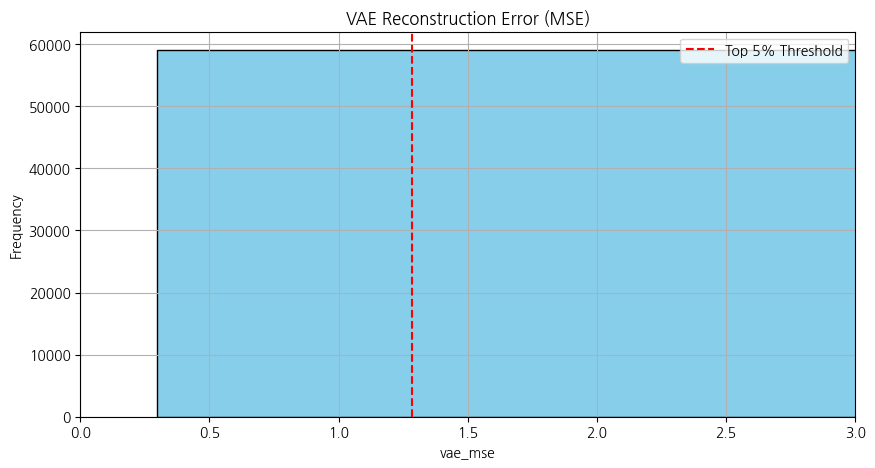

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# MSE 분포 히스토그램 (이상치로 인한 왜곡 방지 위해 xlim 조정)
plt.hist(vae_mse, bins=50, color='skyblue', edgecolor='black')

# 상위 5% 기준선 표시
threshold_95 = np.percentile(vae_mse, 95)
plt.axvline(threshold_95, color='red', linestyle='--', label='Top 5% Threshold')

# 시각적으로 보기 좋은 범위로 x축 제한 설정
plt.xlim(0, 3)

plt.title("VAE Reconstruction Error (MSE)")
plt.xlabel("vae_mse")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

## 1-4. Hybrid Risk Score 계산

In [30]:
# anomaly score를 정규화해서 비교 -> 백분위(rank-based)로 정규화
sampled_df['if_score_norm'] = sampled_df['if_anomaly_score'].rank(pct=True)
sampled_df['ae_score_norm'] = sampled_df['ae_anomaly_score'].rank(pct=True)
sampled_df['vae_score_norm'] = sampled_df['vae_anomaly_score'].rank(pct=True)

# 가중치 설정
alpha_if, alpha_ae, alpha_vae = 0.33, 0.33, 0.34

# Hybrid risk score: 3개 모델의 anomaly score 평균(가중합 방식)
sampled_df['hr_score'] = (alpha_if * sampled_df['if_score_norm'] + alpha_ae * sampled_df['ae_score_norm'] + alpha_vae * sampled_df['vae_score_norm'])

In [31]:
threshold = np.percentile(sampled_df['hr_score'], 95)
sampled_df['hr_anomaly_flag'] = (sampled_df['hr_score'] > threshold).astype(int)

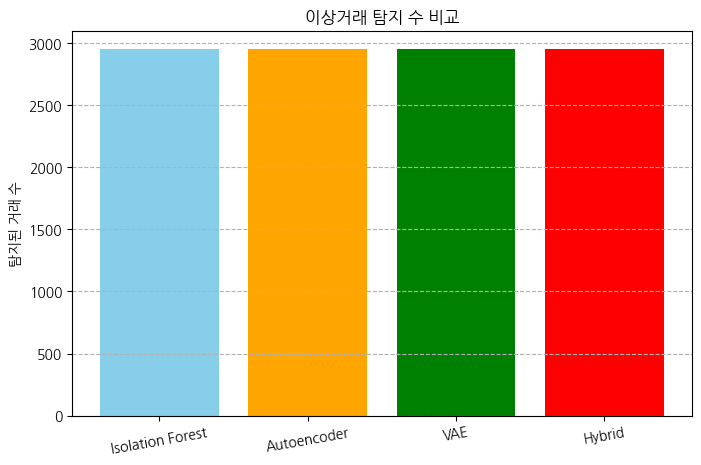

In [32]:
import matplotlib.pyplot as plt

# 각 모델의 이상 플래그 합산 (탐지 개수)
model_names = ['Isolation Forest', 'Autoencoder', 'VAE', 'Hybrid']
counts = [
    sampled_df['if_anomaly_flag'].sum(),
    sampled_df['ae_anomaly_flag'].sum(),
    sampled_df['vae_anomaly_flag'].sum(),
    sampled_df['hr_anomaly_flag'].sum()
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, counts, color=['skyblue', 'orange', 'green', 'red'])
plt.title("이상거래 탐지 수 비교")
plt.ylabel("탐지된 거래 수")
plt.xticks(rotation=10)
plt.grid(axis='y', linestyle='--')
plt.show()

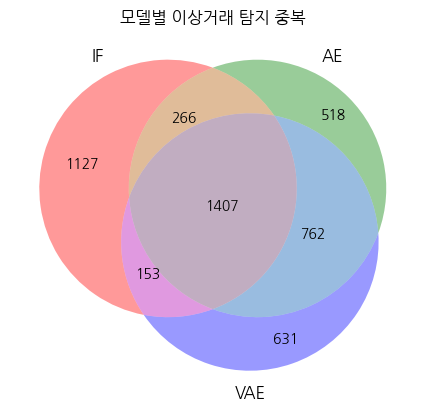

In [33]:
from matplotlib_venn import venn3

# 이상거래 탐지 인덱스 집합
set_if = set(sampled_df[sampled_df['if_anomaly_flag'] == 1].index)
set_ae = set(sampled_df[sampled_df['ae_anomaly_flag'] == 1].index)
set_vae = set(sampled_df[sampled_df['vae_anomaly_flag'] == 1].index)

# 모델 3개만 우선 비교
venn3([set_if, set_ae, set_vae], set_labels=('IF', 'AE', 'VAE'))
plt.title("모델별 이상거래 탐지 중복")
plt.show()

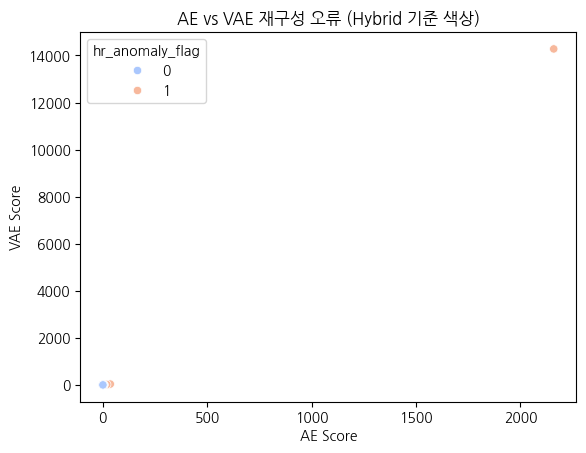

In [34]:
import seaborn as sns

# AE vs VAE Risk score 비교 분포
sns.scatterplot(
    data=sampled_df,
    x='ae_anomaly_score',
    y='vae_anomaly_score',
    hue='hr_anomaly_flag',
    palette='coolwarm'
)
plt.title("AE vs VAE 재구성 오류 (Hybrid 기준 색상)")
plt.xlabel("AE Score")
plt.ylabel("VAE Score")
plt.show()

- score가 낮은 경우(좌하단): 정상 거래일 확률이 높다
- score가 높은 경우(우상단): 재구성 실패, 두 모델에서 모두 이상거래로 간주
- 그런데 좌하단에 이상거래로 간주한 포인트는 어떻게 봐야할까?
  - case 1: IF anomaly score가 매우 높은 경우
    - hr score = alpha_if * if_score + alpha_ae * ae_score + alpha_vae * vae_score
    - if socre가 높다면 평균값이 높아져서 flag = 1로 설정됐을 수 있음
    - 이 경우 '모델 간 판단 불일치'
  - case 2: ae/vae의 점수 스케일이 너무 붙어있는 경우
    - 재구성 오류 분포가 너무 좁은 경우 if가 약간만 크게 작동해도 전체 rank 왜곡 가능
    - 정규화된 rank 스코어 기반 계산의 민감성 문제일 가능
  - case 3: 진짜 이상거래일 수 있음
    - ae/vae는 복원 기반이라 특정 이상패턴을 복원
    - if는 분포 기반 밀도 탐지라 ae/vae에서 놓친 이상거래를 탐지한 것일 수 있음


In [35]:
sampled_df.head(1)

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,if_anomaly_flag,ae_anomaly_score,ae_anomaly_flag,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag
470624,724000.0,20,426528,1.697427,26.15878,0,0,0,0,1,...,0,1.224356,1,1.200564,0,0.923409,0.960341,0.904731,0.929246,1


In [36]:
# case 1에 대한 검증: IF anomaly score가 높은가?
case1_df = sampled_df.copy()
mask = (
    (case1_df['hr_anomaly_flag'] == 1) &
    (case1_df['ae_anomaly_flag'] == 0) &
    (case1_df['vae_anomaly_flag'] == 0)
)

case1_test = case1_df[mask][['if_score_norm', 'ae_score_norm', 'vae_score_norm']]
print(case1_test.sort_values(by = 'if_score_norm', ascending = False).head())

        if_score_norm  ae_score_norm  vae_score_norm
121291       0.995953       0.898144        0.908999
174902       0.995817       0.906374        0.949199
340616       0.995800       0.923883        0.926779
519555       0.995530       0.939428        0.945474
246499       0.994971       0.949809        0.891015


- IF와 ae/vae와의 score 스케일 차이때문에 비교하기 쉽게 정규화한 값으로 비교
- 하이브리드에서 1로 탐지한 경우, IF anomaly score가 타 모델의 score보다 높은 경우가 있다

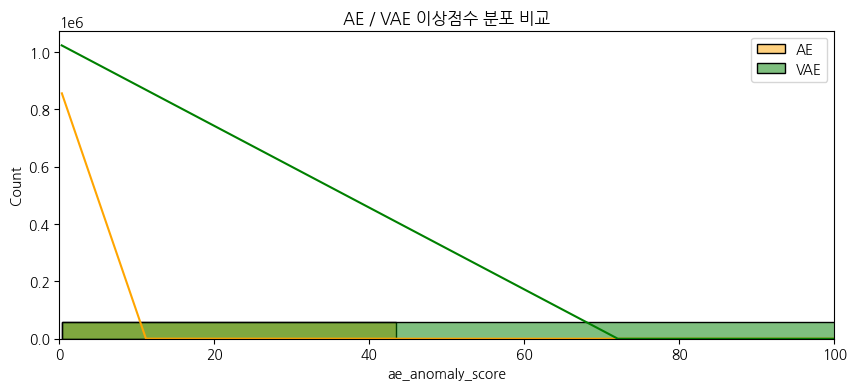

In [37]:
# case 2에 대한 검증: ae/vae의 점수가 근사한가?
# 전체 AE/VAE 점수 분포 확인
import seaborn as sns
import matplotlib.pyplot as plt

case2_df = sampled_df.copy()
plt.figure(figsize=(10, 4))
sns.histplot(case2_df['ae_anomaly_score'], bins=50, kde=True, color='orange', label='AE')
sns.histplot(case2_df['vae_anomaly_score'], bins=50, kde=True, color='green', label='VAE')
plt.xlim(0, 100)
plt.legend()
plt.title("AE / VAE 이상점수 분포 비교")
plt.show()

In [38]:
# case 3에 대한 검증: feature들이 이상 거래
# 이상 거래 의심 feature 중심 비교
case3_df = sampled_df.copy()
cols_to_check = ['vpn', 'rooting', 'is_new_device', 'amount_ratio_to_bank_avg']

case3_test = case3_df[mask][cols_to_check + ['if_anomaly_score']]
display(case3_test.sort_values(by='if_anomaly_score', ascending=False))

,vpn,rooting,is_new_device,amount_ratio_to_bank_avg,if_anomaly_score
121291,0,1,0,7.168747,0.035571
174902,0,0,0,1.060398,0.035239
340616,0,0,1,2.474358,0.035197
519555,0,1,1,4.990112,0.034369
246499,0,1,0,4.591971,0.032540
...,...,...,...,...,...
399133,0,1,0,0.343595,-0.007913
109659,1,1,1,0.281145,-0.008009
244370,0,0,0,0.080511,-0.009328
94050,1,1,0,0.276662,-0.009438


In [39]:
def classify_case(row):
  cv_ae = np.std(sampled_df['ae_anomaly_score'])/np.mean(sampled_df['ae_anomaly_score'])
  cv_vae = np.std(sampled_df['vae_anomaly_score'])/np.mean(sampled_df['vae_anomaly_score'])

  if row['if_anomaly_score'] > np.percentile(sampled_df['if_anomaly_score'], 95):
      return 'Case 1 (IF dominant)'
  elif (cv_ae < 0.1) or (cv_vae < 0.1): # np.std(sampled_df['ae_anomaly_score']) < 0.2) and (np.std(sampled_df['vae_anomaly_score']) < 0.2)
    # 예를들어, 거래1의 ae_score .98 거래 2의 ae_score가 1.00인 경우 각각의 ae percentile rank가 50%, 99.9%라면 score가 아주 작은데도 이상거래로 분류되는 케이스임
    # 그러면 어느정도의 표준편차가 아주 작다고 할 수 있을까? -> coefficient of variation(cv) 사용
    # cv = std/mean
      return 'Case 2 (flat AE/VAE)'
  else:
      return 'Case 3 (plausible anomaly)'

case3_df['case_label'] = case3_df[mask].apply(classify_case, axis=1)

In [40]:
case3_df['case_label'].value_counts()

,count
case_label,
Case 1 (IF dominant),313
Case 3 (plausible anomaly),115


In [43]:
sampled_df.to_csv('/content/drive/MyDrive/FDS/unsuper_df.csv', index=False)

## 데이터 드리프트 metrics

### 데이터 전처리(시계열)

In [ ]:
display(id_df.head(1), sampled_df.head(1))

,TransactionDT,recipient,DeviceInfo,region,receiver_bank,receiver_account,ip_address,app_version,transaction_time
470624,12153579,재호,Unknown,부산,우리은행,1000000445030,179.119.115.145,3.5.6,2025-04-21 20:50:45


,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,if_anomaly_flag,ae_anomaly_score,ae_anomaly_flag,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag
470624,724000.0,20,426528,1.697427,26.15878,0,0,0,0,1,...,0,1.14873,0,1.296469,1,0.923409,0.923578,0.960951,0.936229,1


In [ ]:
timeseries_df = sampled_df.copy()
timeseries_df.head(1)

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,if_anomaly_flag,ae_anomaly_score,ae_anomaly_flag,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag
470624,724000.0,20,426528,1.697427,26.15878,0,0,0,0,1,...,0,1.14873,0,1.296469,1,0.923409,0.923578,0.960951,0.936229,1


In [ ]:
# 테스트를 위해서 시간은 현재기준으로 작성
from datetime import datetime, timedelta
import pytz

# 한국 시간 기준 시작 시각
kst = pytz.timezone("Asia/Seoul")
start_time = datetime.now(kst)

# 전체 row 수
n = len(timeseries_df)

# 60분 동안 발생한 데이터 → 분별 구간 인덱스 생성
minute_bins = np.floor(np.linspace(0, 59, n)).astype(int)

# time_bin 컬럼 생성 (60개 시간대 분포)
timeseries_df['time_bin'] = [start_time + timedelta(minutes=int(m)) for m in minute_bins]

# ISO 포맷으로 포맷팅
timeseries_df['time_bin'] = timeseries_df['time_bin'].dt.strftime("%Y-%m-%dT%H:%M:%S")

In [ ]:
timeseries_df.head()

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,ae_anomaly_score,ae_anomaly_flag,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag,time_bin
470624,724000.0,20,426528,1.697427,26.158780,0,0,0,0,1,...,1.148730,0,1.296469,1,0.923409,0.923578,0.960951,0.936229,1,2025-05-15T20:20:38
565820,108500.0,1,390611,0.277770,148.281147,0,0,1,0,1,...,0.959859,0,1.025192,0,0.348037,0.657517,0.701646,0.570393,0,2025-05-15T20:20:38
284083,47950.0,19,78538,0.610532,97.661782,0,0,0,0,0,...,0.909266,0,0.865984,0,0.290412,0.523606,0.312409,0.374845,0,2025-05-15T20:20:38
239689,100599.0,6,112054,0.897773,37.420775,0,1,0,0,0,...,0.605904,0,0.577253,0,0.028618,0.039337,0.019982,0.029219,0,2025-05-15T20:20:38
281855,107950.0,15,227421,0.474670,24.694017,0,1,0,1,0,...,0.555300,0,0.515276,0,0.020253,0.020541,0.006079,0.015529,0,2025-05-15T20:20:38


In [ ]:
# timeseries_df['transaction_time'] = pd.to_datetime(timeseries_df['transaction_time'])
# timeseries_df['time_bin'] = timeseries_df['transaction_time'].dt.floor('H') # H = 시간 단위, T = 분 단위

### 1. PSI(Population Stability Index)

In [ ]:
def calculate_psi(expected, actual, buckets=10, epsilon=1e-6):
  '''
  두 시점 데이터 분포 차이를 비교해서 얼마나 population이 달라졌는지(불안정해졌는지) 수치로 변환.

  Args:
    expected: 기준 분포 데이터(1D array)
    actual: 비교할 분포 데이터(1D)
    buckets: 구간 수 -> 해당 구간 안에서 값 분포가 얼마나 달라졌는지 계산
    epsilon: 0으로 나누기 방지를 위한 극소값 설정

  Returns:
    float: PSI 값
  '''
  # 구간 설정: 기준 분포를 균등한 분위수로 나누고 경계값 중복 제거)
  breakpoints = np.unique(np.percentile(expected, np.linspace(0, 100, buckets + 1)))

  # 히스토그램 게산: 각 구간에 들어가는 비율 계산
  expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
  actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

  # PSI 계산: 두 분포 차이를 로그비로 측정
  psi = np.sum((expected_counts - actual_counts)*np.log((expected_counts + epsilon)/(actual_counts + epsilon)))
  return psi

### 2. KS-Test(Kolmogorov-Smirnov Test)

In [ ]:
def calculate_ks_test(expected, actual):
  '''
  누적분포 간 최대 차이를 계산해서 두 분포가 다른지 테스트
  p-v가 작을 수록 "차이가 유의미"하다고 판단
  '''
  ks_stat, ks_pval = ks_2samp(expected, actual)
  return ks_stat, ks_pval

### 3. JS Divergence(Jensen-Shannon)

In [ ]:
def calculate_js_divergence(expected, actual, bins=10):
  '''
  두 분포의 "평균적인 정보 차이"를 계산
  값이 0에 가까우면 거의 같고, 1에 가까우면 완전히 다름
  KL Divergence보다 안정적이고 해석이 쉬워서 사용
  '''
  # 히스토그램 기반으로 확률 분포 계산
  expected_hist = np.histogram(expected, bins=bins, density=True)[0]
  actual_hist = np.histogram(actual, bins=bins, density=True)[0]

  # Jensen-Shannon distance를 제곱해서 divergence 값으로 변환
  js_div = jensenshannon(expected_hist, actual_hist)**2
  return js_div

### 4. Wasserstein Distance(Earth Mover's distance)

In [ ]:
def calculate_wasserstein(expected, actual):
  '''
  두 분포의 "평균 거리 차이"를 계산
  물리적으로 데이터를 한 쪽에서 다른 쪽으로 이동시킨다고 한다면, 얼마나 많이 움직여야하는지를 측정하는 방법
  '''
  return wasserstein_distance(expected, actual)

### 5. 통합

In [ ]:
# 기준 설정: 첫 번째 시간 구간을 기준(reference) 구간으로 선택
reference_time = timeseries_df['time_bin'].min()
reference_dist = timeseries_df[timeseries_df['time_bin'] == reference_time]['hr_score']

drift_metrics = []

# 각 시간 구간 마다 드리프트 지표 계산
for t in timeseries_df['time_bin'].sort_values().unique():
  segement = timeseries_df[timeseries_df['time_bin'] == t]['hr_score']

  if len(segement) < 10:
    continue # 데이터 필터링: 표본 수가 너무 적으면 계산 생략

  # PSI: 기존 분포와 비교 분포의 불안정성 측정
  psi = calculate_psi(expected=reference_dist, actual=segement, buckets=10)

  # KS-Test: 기준 구간과 비교 구간의 분포 차이 검정
  ks_stat, ks_pval = calculate_ks_test(expected=reference_dist, actual=segement)

  # JS Divergence: 이산 분포의 유사도 측정
  js_div = calculate_js_divergence(expected=reference_dist, actual=segement, bins=10)

  # Wasserstein Distance: 평균 누적 거리 기반 분포 차이 측정
  wasserstein = calculate_wasserstein(expected=reference_dist, actual=segement)

  # 결과 저장
  drift_metrics.append({
      'time_bin': str(t),
      'psi': psi,
      'ks_pval': ks_pval,
      'js_div': float(js_div),
      'wasserstein': wasserstein
  })

# json
with open('drift_metrics_hourly.json', 'w') as f:
    json.dump(drift_metrics, f, indent=2)

## fastapi (코랩)

In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import json
import nest_asyncio
from pyngrok import ngrok
import os

# Colab 환경에서 asyncio 충돌 해결
nest_asyncio.apply()

# FastAPI 인스턴스 생성
app = FastAPI()

# 데이터 모델 정의
class DriftMetric(BaseModel):
    time_bin: str
    psi: float
    ks_pval: float
    js_div: float
    wasserstein: float

# 그라파나 데이터소스 테스트를 위해 루트 경로 추가
@app.get("/")
def root():
    return {"status": "Drift Metrics API is running"}

# 엔드포인트 정의
@app.get("/drift_metrics")
def get_drift_metrics():
    try:
        with open('drift_metrics_hourly.json', 'r') as f:
            return json.load(f)
    except Exception as e:
        return {"error": str(e)}

# os.path.exists("drift_metrics_hourly.json")

In [ ]:
import json
with open("drift_metrics_hourly.json", "r") as f:
    data = json.load(f)
print(data[:10])  # 일부만 출력

[{'time_bin': '2025-05-12T21:38:45', 'psi': 0.0, 'ks_pval': 1.0, 'js_div': 0.0, 'wasserstein': 0.0}, {'time_bin': '2025-05-12T21:39:45', 'psi': 0.021328954194494317, 'ks_pval': 0.2198793190425799, 'js_div': 0.0018637399002090404, 'wasserstein': 0.01147318281001012}, {'time_bin': '2025-05-12T21:40:45', 'psi': 0.021052894668174126, 'ks_pval': 0.433245729181877, 'js_div': 0.0021192870877762503, 'wasserstein': 0.015102380770244079}, {'time_bin': '2025-05-12T21:41:45', 'psi': 0.019220707433430226, 'ks_pval': 0.14875017642885607, 'js_div': 0.0020882754376889668, 'wasserstein': 0.01820328670550501}, {'time_bin': '2025-05-12T21:42:45', 'psi': 0.031458824361430784, 'ks_pval': 0.08717213195551535, 'js_div': 0.002791542563288262, 'wasserstein': 0.014956073492667123}, {'time_bin': '2025-05-12T21:43:45', 'psi': 0.017350549327859205, 'ks_pval': 0.6108035457934953, 'js_div': 0.002177677350263569, 'wasserstein': 0.0105432282351712}, {'time_bin': '2025-05-12T21:44:45', 'psi': 0.020579546712711647, 'ks_

In [ ]:
# FastAPI 서버 구동
from uvicorn import Config, Server

os.environ["NGROK_AUTH_TOKEN"] = "2wzZEXHBqS0NDi7TTle4E4vTT5p_2CpubUFLj3nKHoF3Z5GC2"
ngrok.set_auth_token(os.environ["NGROK_AUTH_TOKEN"])

# ngrok으로 외부 URL 생성
public_url = ngrok.connect(8000)
print(f"FastAPI is running at {public_url}/drift_metrics")

# 서버 실행
config = Config(app=app, host="0.0.0.0", port=8000, log_level="info")
server = Server(config=config)
server.run()

FastAPI is running at NgrokTunnel: "https://b152-35-221-239-118.ngrok-free.app" -> "http://localhost:8000"/drift_metrics


INFO:     Started server process [20756]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     122.45.130.98:0 - "GET / HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics?psi= HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics?psi= HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics?psi= HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics?psi=1 HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics?psi=1 HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET / HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:0 - "GET /drift_metrics HTTP/1.1" 200 OK
INFO:     122.45.130.98:

## Latent Space 분석

### K-Means

In [ ]:
# VAE에서 계산한 latent_z
latent_z

array([[-6.42014325e-01,  3.37259293e-01,  2.10247219e-01, ...,
         5.08415043e-01,  3.04897547e-01, -1.18658416e-01],
       [-1.18058324e-02,  4.05145943e-01,  7.24567324e-02, ...,
         2.81091869e-01, -1.86272308e-01,  4.33095783e-01],
       [ 3.49452347e-01,  9.06309426e-01,  6.27093196e-01, ...,
         5.00850499e-01,  3.19734961e-01,  1.06720477e-01],
       ...,
       [ 1.22503340e-01,  1.05307376e+00,  3.14968437e-01, ...,
         5.59605658e-01,  5.90069175e-01,  9.33106959e-01],
       [ 4.79687393e-01,  7.99851194e-02,  3.51251781e-01, ...,
        -1.10348895e-01, -8.33496451e-05,  2.53355294e-01],
       [ 3.43940079e-01,  7.02697575e-01,  5.89552701e-01, ...,
         5.39217114e-01,  5.92970133e-01,  4.89077121e-01]], dtype=float32)

In [ ]:
cluster_df = sampled_df.copy()
# cluster_df = cluser_df.drop(columns = cluser_df.loc[:, 'if_anomaly_score':])

In [ ]:
cluster_df.head()

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag,latent_cluster,pca1,pca2
470624,724000.0,20,426528,1.697427,26.158780,0,0,0,0,1,...,1.296469,1,0.923409,0.923578,0.960951,0.936229,1,2,-0.984506,-0.064681
565820,108500.0,1,390611,0.277770,148.281147,0,0,1,0,1,...,1.025192,0,0.348037,0.657517,0.701646,0.570393,0,4,-1.109953,0.010672
284083,47950.0,19,78538,0.610532,97.661782,0,0,0,0,0,...,0.865984,0,0.290412,0.523606,0.312409,0.374845,0,2,-0.562531,-0.159322
239689,100599.0,6,112054,0.897773,37.420775,0,1,0,0,0,...,0.577253,0,0.028618,0.039337,0.019982,0.029219,0,4,-0.905579,-0.174922
281855,107950.0,15,227421,0.474670,24.694017,0,1,0,1,0,...,0.515276,0,0.020253,0.020541,0.006079,0.015529,0,2,-0.664649,0.192062


In [ ]:
np.random.seed()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(latent_z)
cluster_df['latent_cluster'] = cluster_labels

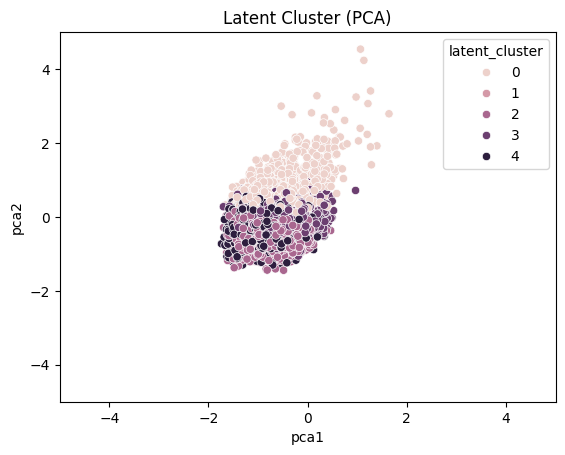

In [ ]:
# 시각화
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_z)
cluster_df['pca1'], cluster_df['pca2'] = latent_2d[:, 0], latent_2d[:, 1]

sns.scatterplot(data = cluster_df, x = 'pca1', y = 'pca2', hue = 'latent_cluster')
plt.title('Latent Cluster (PCA)')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.show()

### UMAP(Uniform Manifold Approximation and Projection)

- 차원 축소: 8차원, 128차원 등 복잡한 feature 공간을 2D/3D로 압축
- 의미 보존: 데이터 간 거리, 군집 구조, 패턴 등을 잘 유지
- 비선형 구조 탐지
- 속도: t-SNE보다 빠르고 scalable
- latent_z를 다룰 때 PCA에 비해 비선형, 그리고 군집 표현력에서 특징과 장점이 있을 것이라 기대

In [ ]:
umap_df = cluster_df.copy()

In [ ]:
# n_neighbors: 작을수록 미세한 클러스터 강조(국소구조 보존 정도)
# min_dis: 점 사이 최소 거리(0에 가까울 수록 클러스터가 더 뚜렷해짐)
reducer = umap.UMAP(n_neighbors = 15, min_dist = 0.1, random_state=42)
umap_embedding = reducer.fit_transform(latent_z)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


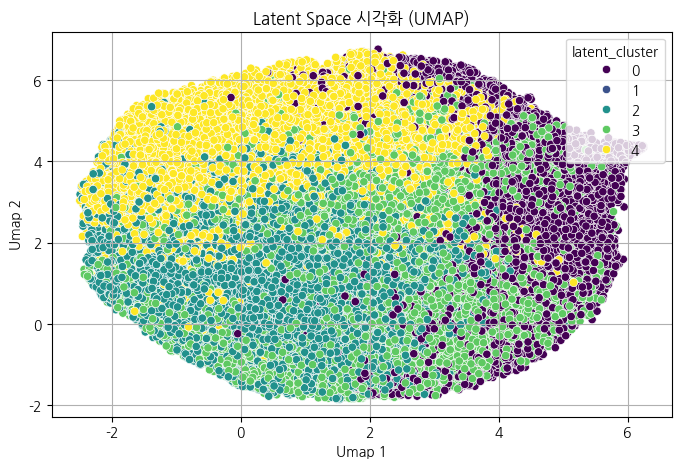

In [ ]:
umap_df['umap1'], umap_df['umap2'] = umap_embedding[:, 0], umap_embedding[:, 1]

plt.figure(figsize = (8, 5))
sns.scatterplot(data = umap_df, x='umap1', y='umap2', hue='latent_cluster', palette='viridis')
plt.title('Latent Space 시각화 (UMAP)')
plt.xlabel('Umap 1')
plt.ylabel('Umap 2')
plt.grid(True)
plt.show()

- VAE의 8차원 latent vector -> 2D로 축소(UMAP)
- 경계가 어느정도 있으므로 패턴 차이는 있다
- 같은 구조 내에 작은 차이가 클러스터 간 유사성으로 표현됨
- 클러스터별 위험도를 해석해보기

In [ ]:
cluster_summary = cluster_df.groupby('latent_cluster').agg({
    'hr_score': 'mean',
    'hr_anomaly_flag': 'mean',
    'TransactionAmt': 'mean',
    'voice_match': 'mean',
    'is_new_account_for_user': 'mean',
    'is_nighttime': 'mean',
    'vpn': 'mean',
    'rooting': 'mean',
    'is_new_device': 'mean',
    'amount_ratio_to_bank_avg': 'mean'
}).rename(columns={'hr_anomaly_flag': 'anomaly_rate'})
cluster_summary

,hr_score,anomaly_rate,TransactionAmt,voice_match,is_new_account_for_user,is_nighttime,vpn,rooting,is_new_device,amount_ratio_to_bank_avg
latent_cluster,,,,,,,,,,
0,0.563131,0.116962,2.276575e+05,0.374691,0.361707,0.395404,0.511232,0.473825,0.513912,1.251978
1,0.999832,1.000000,3.193739e+07,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,606.264185
2,0.479181,0.027986,1.038120e+05,0.515398,0.529567,0.213934,0.544965,0.513232,0.480445,0.495019
3,0.495334,0.041505,1.291500e+05,0.484243,0.573420,0.244958,0.436818,0.451681,0.531545,0.645792
4,0.488702,0.041485,1.169675e+05,0.570886,0.475396,0.204746,0.515635,0.546780,0.468793,0.594857


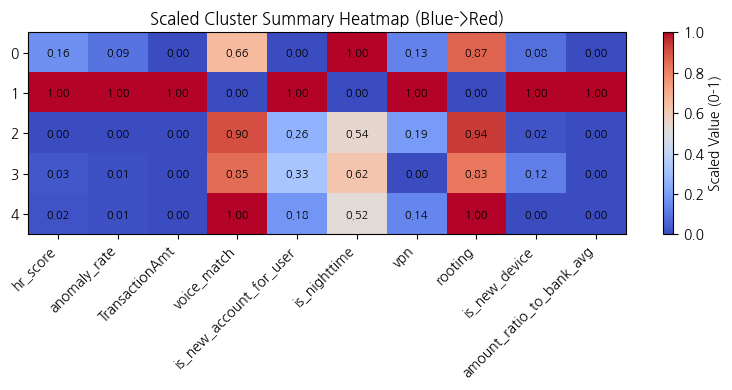

In [ ]:
# Min-Max 스케일링 (0~1)
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(cluster_summary)
scaled_df = pd.DataFrame(scaled_values, index=cluster_summary.index, columns=cluster_summary.columns)

# 히트맵 그리기 및 수치 표시, coolwarm 컬러맵 사용 (파란->빨간)
plt.figure(figsize=(8, 4))
im = plt.imshow(scaled_df, aspect='auto', cmap='coolwarm')
plt.colorbar(im, label='Scaled Value (0-1)')
plt.xticks(range(len(scaled_df.columns)), scaled_df.columns, rotation=45, ha='right')
plt.yticks(range(len(scaled_df.index)), scaled_df.index)

# 셀마다 숫자 텍스트 추가
for i in range(scaled_df.shape[0]):
    for j in range(scaled_df.shape[1]):
        plt.text(j, i, f"{scaled_df.iat[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.title('Scaled Cluster Summary Heatmap (Blue->Red)')
plt.tight_layout()
plt.show()

- hr_score로만 보면 가장 고위험 거래는 클러스터 0에서 발생
- 하지만 이상 거래는 클러스터 3에서 더 많이 발생
- 일단 클러스터 3은 보내는 송금액과 평균 송금액이 높은 편이라, 이런 요인때문에 이상 거래가 발생하는 것으로 파악(금액 요인이 중심)
- 클러스터 0의 경우 부분은 금액이 낮고, 평균 송금액도 낮은 편이다. 다만 feature들의 조합들로 인해 anomaly_score가 높다(시스템적인 위험 요인이 중심)
- 두 클러스터 0, 3의 탐지 방식의 차이가 명확함
  - 클러스터 0: hr_score가 높은 것은 모델링의 결과
  - 클러스터 3: anomaly_rate(anomaly_flag)는 탐지 임계점(threshold)에 의해 걸러진 패턴임
  - 두 클러스터는 서로 다른 탐지 기준을 반영한 결과

### FAMD(Factor Analysis of Mixed Data)

In [ ]:
famd_df = sampled_df.copy()

In [ ]:
# famd_df = famd_df.drop(columns = famd_df.loc[:, 'if_anomaly_score':])
famd_df.head()

,TransactionAmt,hour,avg_amount_to_bank,amount_ratio_to_bank_avg,recent_transaction_gap,voice_match,is_new_account_for_user,is_nighttime,is_new_device,vpn,...,if_anomaly_flag,ae_anomaly_score,ae_anomaly_flag,vae_anomaly_score,vae_anomaly_flag,if_score_norm,ae_score_norm,vae_score_norm,hr_score,hr_anomaly_flag
470624,724000.0,20,426528,1.697427,26.158780,0,0,0,0,1,...,0,1.148730,0,1.296469,1,0.923409,0.923578,0.960951,0.936229,1
565820,108500.0,1,390611,0.277770,148.281147,0,0,1,0,1,...,0,0.959859,0,1.025192,0,0.348037,0.657517,0.701646,0.570393,0
284083,47950.0,19,78538,0.610532,97.661782,0,0,0,0,0,...,0,0.909266,0,0.865984,0,0.290412,0.523606,0.312409,0.374845,0
239689,100599.0,6,112054,0.897773,37.420775,0,1,0,0,0,...,0,0.605904,0,0.577253,0,0.028618,0.039337,0.019982,0.029219,0
281855,107950.0,15,227421,0.474670,24.694017,0,1,0,1,0,...,0,0.555300,0,0.515276,0,0.020253,0.020541,0.006079,0.015529,0


In [ ]:
import prince

# 1. 모델 초기화 -> 학습
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine='sklearn'
)

famd = famd.fit(famd_df)

/usr/local/lib/python3.11/dist-packages/prince/famd.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.02233505 -0.00033145 -0.00640308 ...  0.02133151 -0.029885
 -0.0012674 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_num[:] = self.num_scaler_.transform(X_num)
/usr/local/lib/python3.11/dist-packages/prince/famd.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.0041083  -0.00411397 -0.0041173  ... -0.00411231 -0.004121
 -0.00411676]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_num[:] = self.num_scaler_.transform(X_num)


In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(famd_result)

In [ ]:
famd_df.head()

In [ ]:
# 2. 결과 확인
print('\n===== 고유값 및 설명된 분산 확인 =====')
print(famd.eigenvalues_summary)

# row 주성분 좌표 확인
row_coords = famd.row_coordinates(famd_df)
print('\n===== row의 주성분 좌표 확인(top 5) =====')
print(row_coords.head())

# col 주성분 좌표 확인
col_coords = famd.column_coordinates_
print('\n===== col의 주성분 좌표 확인 =====')
print(col_coords)


===== 고유값 및 설명된 분산 확인 =====
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0             15.448         6.23%                      6.23%
1             15.332         6.18%                     12.41%

===== row의 주성분 좌표 확인(top 5) =====
component         0         1
0         -0.024169  2.128186
1         -2.241195 -0.676050
2          4.725505 -3.560774
3         -2.509044 -5.814015
4          2.685966 -5.072426

===== col의 주성분 좌표 확인 =====
component                           0             1
variable                                           
transaction_amount           0.000022  9.285307e-06
hour                         0.000478  9.747885e-04
avg_amount_to_bank           0.000020  8.014447e-06
amount_ratio_to_bank_avg     0.000025  1.089221e-05
recent_transaction_gap       0.000006  5.387017e-07
day_of_week                  0.000045  1.090436e-05
authentication_2             0.000565  1.618160e-04
authenticati

In [ ]:
print(f"NaN 값 개수: {famd_df.isna().sum().sum()}")

print(f"무한대 값 개수: {(np.isinf(famd_df.values)).sum()}")

NaN 값 개수: 0
무한대 값 개수: 0


In [ ]:
# 3. 시각화
try:
    row_coords = famd.row_coordinates(famd_df) # 또는 원본 데이터 X
    col_coords = famd.column_coordinates_ # 또는 column_correlations(X) 등

    # Plotly는 DataFrame을 선호
    row_coords_df = pd.DataFrame(row_coords.values, index=row_coords.index, columns=[f'Component {i}' for i in range(row_coords.shape[1])])
    col_coords_df = pd.DataFrame(col_coords.values, index=col_coords.index, columns=[f'Component {i}' for i in range(col_coords.shape[1])])

    # 개체 시각화
    fig_rows = px.scatter(row_coords_df, x='Component 0', y='Component 1',
                          text=row_coords_df.index, # 마우스 오버 시 레이블 표시
                          title='FAMD Individuals (Plotly)')
    fig_rows.update_traces(textposition='top center')
    fig_rows.show()

    # 변수 시각화 (원점에서 시작하는 화살표 형태로 그리는 것이 일반적)
    # Plotly로 Correlation Circle 유사하게 그리려면 조금 더 복잡한 설정 필요
    # 여기서는 간단히 변수 좌표 산점도로 표시
    fig_cols = px.scatter(col_coords_df, x='Component 0', y='Component 1',
                          text=col_coords_df.index,
                          title='FAMD Variables (Plotly)')
    fig_cols.update_traces(textposition='top center')

    # 원점 및 축 추가
    fig_cols.add_shape(type="line", x0=0, y0=min(col_coords_df['Component 1'])-0.1, x1=0, y1=max(col_coords_df['Component 1'])+0.1, line=dict(color="grey",width=1))
    fig_cols.add_shape(type="line", x0=min(col_coords_df['Component 0'])-0.1, y0=0, x1=max(col_coords_df['Component 0'])+0.1, y1=0, line=dict(color="grey",width=1))
    fig_cols.show()

except Exception as e:
    print(f"Plotly 시각화 중 오류 발생: {e}")
    print("FAMD 객체에서 좌표를 올바르게 추출했는지 확인하세요.")

- 변수 해석
> n_component = 2인 경우,
> component 0:
intent > payment_method > browser 순으로 양의 관계, intent를 대표하는 주성분
> component 1: browser > payment_method 순서이지만 사실 browser와 다른 변수(특히 intent)를 구분하는 주성분

In [ ]:
try:
    famd = prince.FAMD(
    n_components=3,
    n_iter=10,
    copy=True,
    check_input=True,
    random_state=42,
    engine='sklearn'
    )

    famd = famd.fit(famd_df)
    print("\n--- 설명된 분산 정보 (eigenvalues_summary) ---")
    summary = famd.eigenvalues_summary
    print(summary)

    # 만약 특정 차원의 설명 분산 비율(%)만 필요하다면:
    explained_variance_ratio = summary['% of variance']
    print("\n--- 각 차원의 설명 분산 비율 (%) ---")
    print(explained_variance_ratio)

    # *** 수정된 부분: 정확한 열 이름 사용 ***
    cumulative_variance_ratio = summary['% of variance (cumulative)'] # 괄호 포함
    print("\n--- 누적 설명 분산 비율 (%) ---")
    print(cumulative_variance_ratio)

    # 이후 분석 또는 시각화 진행
    # 예: 개체 좌표 얻기
    row_coords = famd.transform(df) # transform 사용 가능 (fit_transform도 가능)
    print("\n--- 개체 좌표 (상위 5개) ---")
    print(row_coords.head())

    # col 주성분 좌표 확인
    col_coords = famd.column_coordinates_
    print('\n===== col의 주성분 좌표 확인 =====')
    print(col_coords)

except KeyError as e:
    print(f"\n[오류 발생] KeyError: 열 이름 '{e}'을(를) 찾을 수 없습니다.")
    print("DataFrame의 실제 열 이름을 확인하고 코드를 수정하세요.")

    if 'summary' in locals(): # summary 변수가 생성되었는지 확인
        print("사용 가능한 열 이름:", summary.columns.tolist()) # 실제 열 이름 목록 출력

except Exception as e:
    print(f"FAMD 모델 학습 또는 결과 확인 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()


--- 설명된 분산 정보 (eigenvalues_summary) ---
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0             15.592         6.29%                      6.29%
1             15.494         6.25%                     12.53%
2             15.409         6.21%                     18.75%

--- 각 차원의 설명 분산 비율 (%) ---
component
0    6.29%
1    6.25%
2    6.21%
Name: % of variance, dtype: object

--- 누적 설명 분산 비율 (%) ---
component
0     6.29%
1    12.53%
2    18.75%
Name: % of variance (cumulative), dtype: object

--- 개체 좌표 (상위 5개) ---
component         0         1         2
0          1.568452  5.247061  6.128534
1          0.966806 -3.450636 -6.207823
2         -5.182280 -3.677756  0.098771
3          1.351313 -3.394406  6.286325
4         -4.926910 -3.461712 -0.029540

===== col의 주성분 좌표 확인 =====
component                               0             1             2
variable                                                       

In [ ]:
famd.column_coordinates_

component,0,1,2
variable,,,
transaction_amount,2.401897e-05,1.376345e-06,1.347687e-07
hour,1.803305e-04,2.430966e-05,4.080129e-05
avg_amount_to_bank,1.337623e-05,1.193114e-05,2.959897e-06
amount_ratio_to_bank_avg,3.136117e-05,4.741949e-07,9.760707e-09
recent_transaction_gap,9.242344e-06,2.234522e-07,2.849520e-06
day_of_week,3.750932e-05,2.647109e-05,3.265428e-06
authentication_2,1.114823e-05,7.296388e-07,6.546954e-05
authentication_3,4.291177e-04,3.277153e-05,7.887267e-08
authentication_4,1.336560e-07,1.022720e-04,1.535927e-04


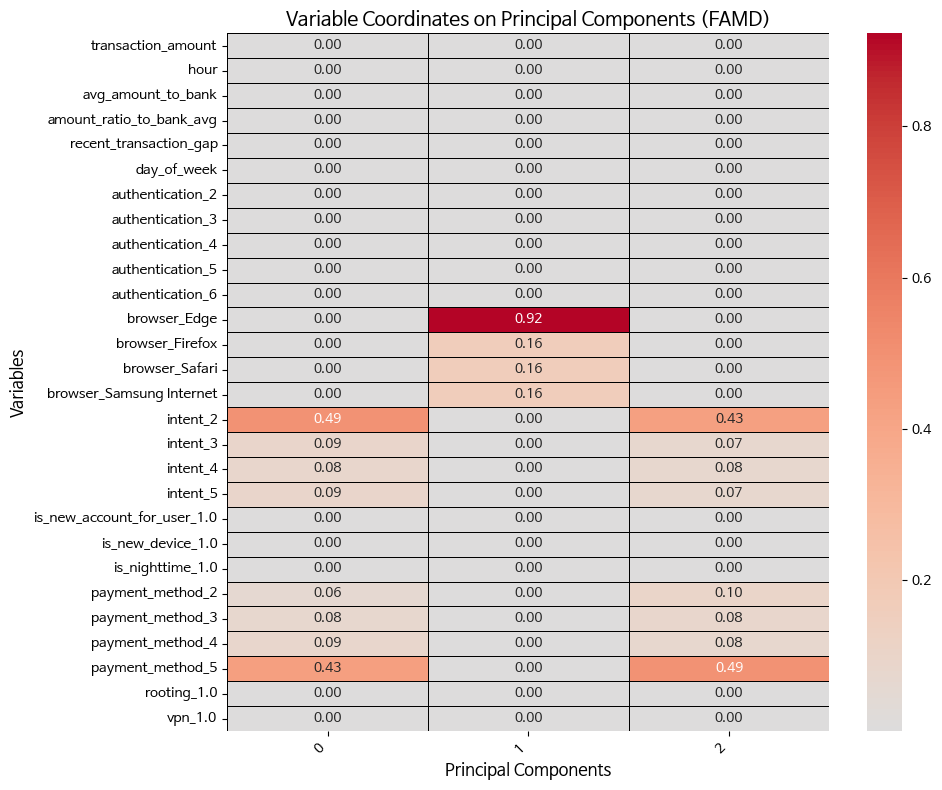

In [ ]:
%matplotlib inline
plt.figure(figsize=(10, 8)) # 그래프 크기 설정

# seaborn.heatmap 함수 사용
# annot=True: 각 셀에 좌표 값을 표시
# cmap='coolwarm': 파란색(음수)-흰색(0 근처)-빨간색(양수)으로 표현되는 발산형 컬러맵을 사용
# 좌표의 부호(+/-)를 직관적으로 보여줍니다. 다른 cmap (예: 'RdBu_r', 'vlag')도 가능
# center=0: 컬러맵의 중앙값을 0으로 설정하여 양수와 음수를 구분
# fmt=".2f": 셀에 표시될 숫자의 형식을 소수점 둘째 자리까지로 지정
# linewidths=.5: 셀 사이에 가는 실선을 추가하여 구분
# linecolor='black': 셀 사이 실선의 색상을 지정합니다

heatmap = sns.heatmap(
    famd.column_coordinates_,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=.5,
    linecolor='black',
    cbar=True # 컬러바 표시 (기본값 True)
)

plt.title('Variable Coordinates on Principal Components (FAMD)', fontsize=14) # 그래프 제목 설정
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 그래프 보여주기
plt.show()

### DBSCAN

In [ ]:
transformed_data = famd.transform(famd_df)
transformed_data.index = famd_df.index

# 1. DBSCAN 모델 정의 및 학습 (적절한 eps, min_samples 값 지정 필요)
dbscan = DBSCAN(eps=0.6, min_samples=5)
cluster_labels = dbscan.fit_predict(transformed_data)

# 2. 결과를 데이터프레임에 칼럼으로 추가
famd_df['cluster'] = cluster_labels

# 3. id 정보가 담긴 df_id와 병합
df_result = pd.concat([df['user_id'], famd_df[['cluster']]], axis=1)

# 4. 결과 출력 예시
print(df_result.head())

     user_id  cluster
0  user_5552        0
1  user_7227        1
2    unknown        2
3  user_1188        3
4  user_4923        2


In [ ]:
# 4 minority cluster
df_result['cluster'].value_counts().sort_values().head(4)

,count
cluster,
26,437
24,891
20,921
21,954


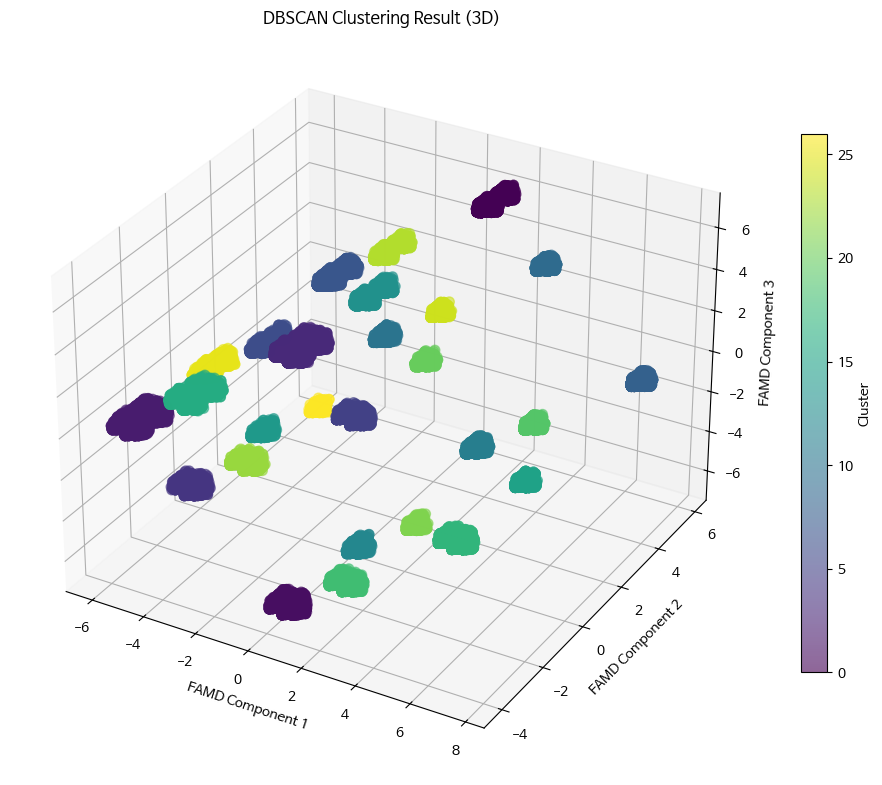

In [ ]:
# 3D 플롯 생성
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')  # projection='3d'로 3D 플롯 설정

# transformed_data를 사용하여 3D 산점도 그리기
# x, y, z축에 각각 FAMD의 1, 2, 3번째 주성분을 사용
# hue는 cluster_labels를 사용하여 클러스터별로 색상을 다르게 표시
# palette는 'viridis'를 사용 (다른 팔레트도 가능)
scatter = ax.scatter(transformed_data[0], transformed_data[1], transformed_data[2],
                     c=cluster_labels, cmap='viridis', s=50, alpha=0.6)

# 축 레이블 설정
ax.set_xlabel('FAMD Component 1')
ax.set_ylabel('FAMD Component 2')
ax.set_zlabel('FAMD Component 3')

# 그래프 제목 설정
ax.set_title('DBSCAN Clustering Result (3D)')

# 컬러바 추가 (클러스터 레이블과 색상 매핑 표시)
fig.colorbar(scatter, label='Cluster', shrink=0.7, aspect=20)

# 그래프 보여주기
plt.show()